In [2]:
import duckdb
import pandas as pd

con = duckdb.connect("developer_project.duckdb")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


In [3]:
con.execute("""
CREATE OR REPLACE TABLE activity_user_features AS
SELECT
    dev_contact AS developer_id,

    COUNT(*) AS total_activities_all_time,
    COUNT(DISTINCT activity_name) AS distinct_activities_all_time,
    COUNT(DISTINCT activity_category) AS distinct_categories_all_time,

    SUM(activity_score) AS total_activity_score_all_time,
    AVG(activity_score) AS avg_activity_score_all_time,
    MAX(activity_date) AS most_recent_activity_date,
    MIN(activity_date) AS first_seen_activity_date,
    DATE_DIFF('day', MAX(activity_date), CURRENT_DATE) AS days_since_last_activity,

    SUM(CASE WHEN activity_date >= CURRENT_DATE - INTERVAL 30 DAY THEN 1 ELSE 0 END) AS activity_cnt_30d,
    SUM(CASE WHEN activity_date >= CURRENT_DATE - INTERVAL 90 DAY THEN 1 ELSE 0 END) AS activity_cnt_90d,
    SUM(CASE WHEN activity_date >= CURRENT_DATE - INTERVAL 180 DAY THEN 1 ELSE 0 END) AS activity_cnt_180d,
    SUM(CASE WHEN activity_date >= CURRENT_DATE - INTERVAL 360 DAY THEN 1 ELSE 0 END) AS activity_cnt_360d,

    SUM(CASE WHEN activity_date >= CURRENT_DATE - INTERVAL 30 DAY THEN activity_score ELSE 0 END) AS activity_score_30d,
    SUM(CASE WHEN activity_date >= CURRENT_DATE - INTERVAL 90 DAY THEN activity_score ELSE 0 END) AS activity_score_90d,
    SUM(CASE WHEN activity_date >= CURRENT_DATE - INTERVAL 180 DAY THEN activity_score ELSE 0 END) AS activity_score_180d,
    SUM(CASE WHEN activity_date >= CURRENT_DATE - INTERVAL 360 DAY THEN activity_score ELSE 0 END) AS activity_score_360d,

    SUM(CASE WHEN activity_category = 'exploring' AND activity_date >= CURRENT_DATE - INTERVAL 30 DAY THEN 1 ELSE 0 END) AS exploring_cnt_30d,
    SUM(CASE WHEN activity_category = 'learning' AND activity_date >= CURRENT_DATE - INTERVAL 30 DAY THEN 1 ELSE 0 END) AS learning_cnt_30d,
    SUM(CASE WHEN activity_category = 'building' AND activity_date >= CURRENT_DATE - INTERVAL 30 DAY THEN 1 ELSE 0 END) AS building_cnt_30d,
    SUM(CASE WHEN activity_category = 'contributing' AND activity_date >= CURRENT_DATE - INTERVAL 30 DAY THEN 1 ELSE 0 END) AS contributing_cnt_30d
FROM activity_final
GROUP BY dev_contact
""")

100% ▕██████████████████████████████████████▏ (00:00:14.36 elapsed)     


In [4]:
con.execute("""
CREATE OR REPLACE TABLE developer_feature_base AS
SELECT
    c.developer_id,
    c.program_application_source,
    c.country,
    c.region,
    c.sub_region,
    c.zone,
    c.territory,
    c.organization_english_name,
    c.development_areas,
    c.industry_segment_vertical,
    c.fields_of_interest,
    c.first_program_application_date,
    c.account_id,
    c.account_name,
    c.last_activity_date,
    c.last_modified_date,
    c.created_date,
    c.wwfo_category,
    c.account_industry_segment,
    c.account_source,
    c.account_type,
    c.devzone_last_login_date,
    c.organization_website,
    c.inception_id,
    c.first_activity_date,
    c.normalized_account_name,
    c.rdp_exit_date,

    COALESCE(a.total_activities_all_time, 0) AS total_activities_all_time,
    COALESCE(a.distinct_activities_all_time, 0) AS distinct_activities_all_time,
    COALESCE(a.distinct_categories_all_time, 0) AS distinct_categories_all_time,
    COALESCE(a.total_activity_score_all_time, 0) AS total_activity_score_all_time,
    COALESCE(a.avg_activity_score_all_time, 0) AS avg_activity_score_all_time,
    a.most_recent_activity_date,
    a.first_seen_activity_date,
    COALESCE(a.days_since_last_activity, 99999) AS days_since_last_activity,
    COALESCE(a.activity_cnt_30d, 0) AS activity_cnt_30d,
    COALESCE(a.activity_cnt_90d, 0) AS activity_cnt_90d,
    COALESCE(a.activity_cnt_180d, 0) AS activity_cnt_180d,
    COALESCE(a.activity_cnt_360d, 0) AS activity_cnt_360d,
    COALESCE(a.activity_score_30d, 0) AS activity_score_30d,
    COALESCE(a.activity_score_90d, 0) AS activity_score_90d,
    COALESCE(a.activity_score_180d, 0) AS activity_score_180d,
    COALESCE(a.activity_score_360d, 0) AS activity_score_360d,
    COALESCE(a.exploring_cnt_30d, 0) AS exploring_cnt_30d,
    COALESCE(a.learning_cnt_30d, 0) AS learning_cnt_30d,
    COALESCE(a.building_cnt_30d, 0) AS building_cnt_30d,
    COALESCE(a.contributing_cnt_30d, 0) AS contributing_cnt_30d
FROM contact_final c
LEFT JOIN activity_user_features a
    ON c.developer_id = a.developer_id
""")


100% ▕██████████████████████████████████████▏ (00:00:06.61 elapsed)     


In [5]:
print(con.execute("""
SELECT COUNT(*) AS row_count,
       COUNT(DISTINCT developer_id) AS distinct_users
FROM developer_feature_base
""").fetchdf())

print(con.execute("""
SELECT
    COUNT(DISTINCT c.developer_id) AS total_contact_users,
    COUNT(DISTINCT a.developer_id) AS matched_activity_users,
    COUNT(DISTINCT c.developer_id) - COUNT(DISTINCT a.developer_id) AS users_without_activity
FROM contact_final c
LEFT JOIN activity_user_features a
    ON c.developer_id = a.developer_id
""").fetchdf())

   row_count  distinct_users
0    9381490         9381490
   total_contact_users  matched_activity_users  users_without_activity
0              9381490                 7654410                 1727080


In [6]:
print("Final row count and distinct users:")
print(con.execute("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT developer_id) AS distinct_users
FROM developer_feature_base
""").fetchdf())

print("\nDuplicate developer_id check in final table:")
print(con.execute("""
SELECT developer_id, COUNT(*) AS cnt
FROM developer_feature_base
GROUP BY developer_id
HAVING COUNT(*) > 1
LIMIT 20
""").fetchdf())

print("\nMissing developer_id check in final table:")
print(con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN developer_id IS NULL OR TRIM(developer_id) = '' THEN 1 ELSE 0 END) AS missing_developer_id
FROM developer_feature_base
""").fetchdf())

print("\nJoin coverage: how many contact users matched activity:")
print(con.execute("""
SELECT
    COUNT(DISTINCT c.developer_id) AS total_contact_users,
    COUNT(DISTINCT a.developer_id) AS matched_activity_users,
    COUNT(DISTINCT c.developer_id) - COUNT(DISTINCT a.developer_id) AS users_without_activity
FROM contact_final c
LEFT JOIN activity_user_features a
    ON c.developer_id = a.developer_id
""").fetchdf())

print("\nSample users with no matched activity:")
print(con.execute("""
SELECT c.developer_id
FROM contact_final c
LEFT JOIN activity_user_features a
    ON c.developer_id = a.developer_id
WHERE a.developer_id IS NULL
LIMIT 20
""").fetchdf())

print("\nFeature null checks in final table:")
print(con.execute("""
SELECT
    SUM(CASE WHEN total_activities_all_time IS NULL THEN 1 ELSE 0 END) AS null_total_activities,
    SUM(CASE WHEN total_activity_score_all_time IS NULL THEN 1 ELSE 0 END) AS null_total_score,
    SUM(CASE WHEN days_since_last_activity IS NULL THEN 1 ELSE 0 END) AS null_days_since_last_activity
FROM developer_feature_base
""").fetchdf())

print("\nFeature distribution summary:")
print(con.execute("""
SELECT
    MIN(total_activities_all_time) AS min_total_activities,
    MAX(total_activities_all_time) AS max_total_activities,
    AVG(total_activities_all_time) AS avg_total_activities,
    MIN(total_activity_score_all_time) AS min_total_score,
    MAX(total_activity_score_all_time) AS max_total_score,
    AVG(total_activity_score_all_time) AS avg_total_score
FROM developer_feature_base
""").fetchdf())

print("\nRecent activity window checks:")
print(con.execute("""
SELECT
    SUM(CASE WHEN activity_cnt_30d > activity_cnt_90d THEN 1 ELSE 0 END) AS bad_30_gt_90,
    SUM(CASE WHEN activity_cnt_90d > activity_cnt_180d THEN 1 ELSE 0 END) AS bad_90_gt_180,
    SUM(CASE WHEN activity_cnt_180d > activity_cnt_360d THEN 1 ELSE 0 END) AS bad_180_gt_360
FROM developer_feature_base
""").fetchdf())

print("\nScore window checks:")
print(con.execute("""
SELECT
    SUM(CASE WHEN activity_score_30d > activity_score_90d THEN 1 ELSE 0 END) AS bad_score_30_gt_90,
    SUM(CASE WHEN activity_score_90d > activity_score_180d THEN 1 ELSE 0 END) AS bad_score_90_gt_180,
    SUM(CASE WHEN activity_score_180d > activity_score_360d THEN 1 ELSE 0 END) AS bad_score_180_gt_360
FROM developer_feature_base
""").fetchdf())

print("\nTop 20 most active users:")
print(con.execute("""
SELECT developer_id, total_activities_all_time, total_activity_score_all_time
FROM developer_feature_base
ORDER BY total_activities_all_time DESC, total_activity_score_all_time DESC
LIMIT 20
""").fetchdf())

print("\nPreview final joined dataset:")
print(con.execute("""
SELECT *
FROM developer_feature_base
LIMIT 20
""").fetchdf())

Final row count and distinct users:
   row_count  distinct_users
0    9381490         9381490

Duplicate developer_id check in final table:
Empty DataFrame
Columns: [developer_id, cnt]
Index: []

Missing developer_id check in final table:
   total_rows  missing_developer_id
0     9381490                   0.0

Join coverage: how many contact users matched activity:
   total_contact_users  matched_activity_users  users_without_activity
0              9381490                 7654410                 1727080

Sample users with no matched activity:
   developer_id
0      10082401
1      10082531
2      10089169
3      10089208
4      10090042
5      10091753
6      10091858
7      10091907
8      10092040
9      10092195
10     10092664
11     10092715
12     10092999
13     10093711
14     10097911
15     10098464
16     10099123
17     10099344
18     10099446
19     10101836

Feature null checks in final table:
   null_total_activities  null_total_score  null_days_since_last_activity
0  

In [7]:
con.execute("""SHOW TABLES""").fetchdf()

,name
0,activity_capped
1,activity_clean
2,activity_final
3,activity_raw
4,activity_sample
5,activity_score_bounds
6,activity_score_mapping_clean
7,activity_score_mapping_raw
8,activity_scored
9,activity_stage


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

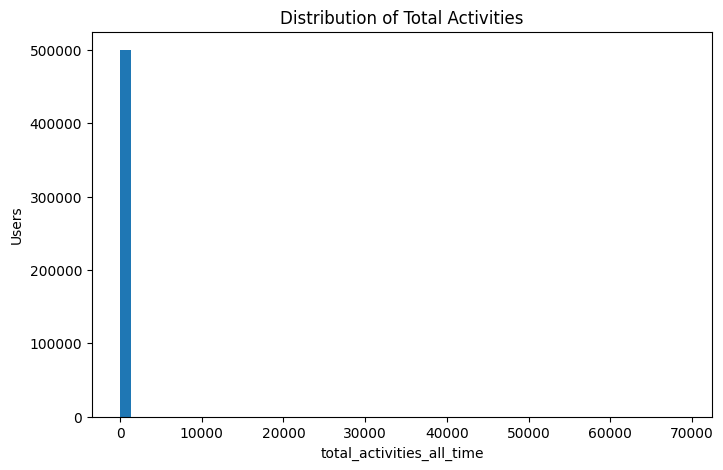

In [9]:
df = con.execute("""
SELECT total_activities_all_time
FROM developer_feature_base
WHERE total_activities_all_time IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8,5))
plt.hist(df["total_activities_all_time"], bins=50)
plt.title("Distribution of Total Activities")
plt.xlabel("total_activities_all_time")
plt.ylabel("Users")
plt.show()

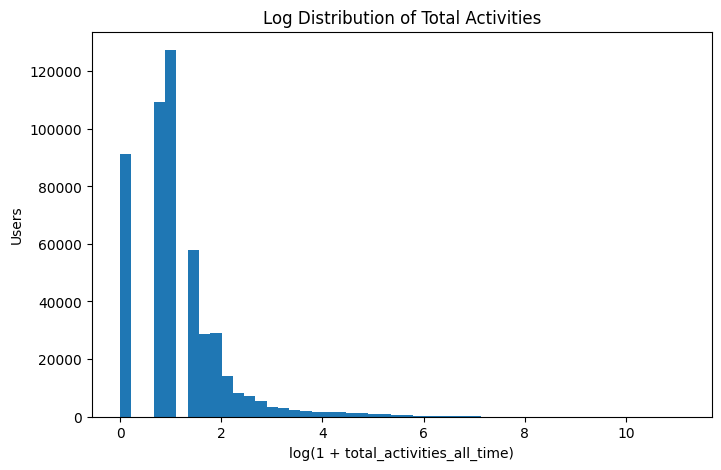

In [10]:
df = con.execute("""
SELECT LN(1 + total_activities_all_time) AS log_total_activities
FROM developer_feature_base
WHERE total_activities_all_time IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8,5))
plt.hist(df["log_total_activities"], bins=50)
plt.title("Log Distribution of Total Activities")
plt.xlabel("log(1 + total_activities_all_time)")
plt.ylabel("Users")
plt.show()

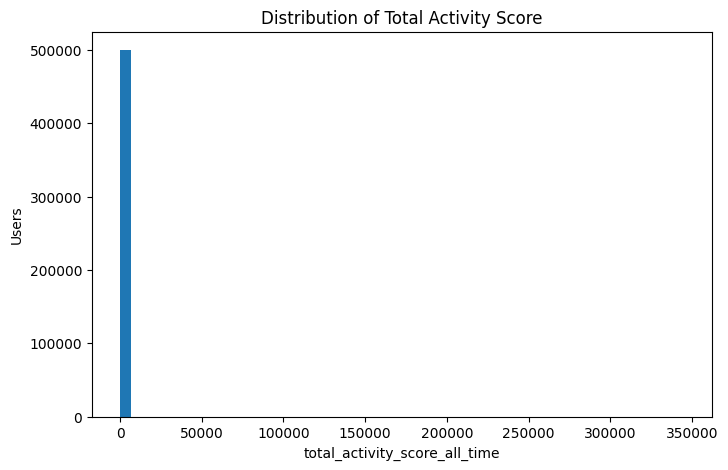

In [11]:
df = con.execute("""
SELECT total_activity_score_all_time
FROM developer_feature_base
WHERE total_activity_score_all_time IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8,5))
plt.hist(df["total_activity_score_all_time"], bins=50)
plt.title("Distribution of Total Activity Score")
plt.xlabel("total_activity_score_all_time")
plt.ylabel("Users")
plt.show()

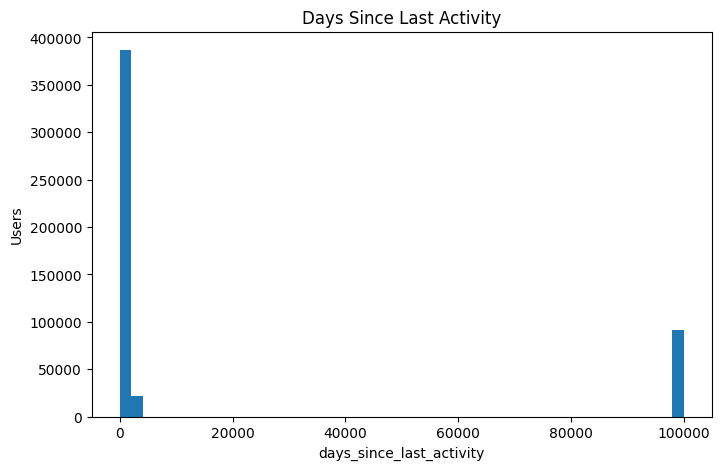

In [12]:
df = con.execute("""
SELECT days_since_last_activity
FROM developer_feature_base
WHERE days_since_last_activity IS NOT NULL
LIMIT 500000
""").fetchdf()

plt.figure(figsize=(8,5))
plt.hist(df["days_since_last_activity"], bins=50)
plt.title("Days Since Last Activity")
plt.xlabel("days_since_last_activity")
plt.ylabel("Users")
plt.show()

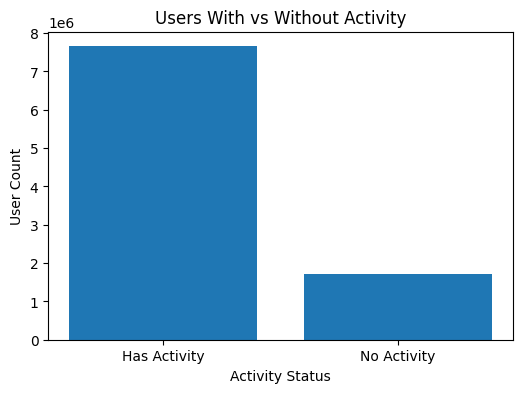

In [13]:
df = con.execute("""
SELECT
    CASE
        WHEN total_activities_all_time = 0 THEN 'No Activity'
        ELSE 'Has Activity'
    END AS activity_status,
    COUNT(*) AS user_count
FROM developer_feature_base
GROUP BY 1
ORDER BY 2 DESC
""").fetchdf()

plt.figure(figsize=(6,4))
plt.bar(df["activity_status"], df["user_count"])
plt.title("Users With vs Without Activity")
plt.xlabel("Activity Status")
plt.ylabel("User Count")
plt.show()

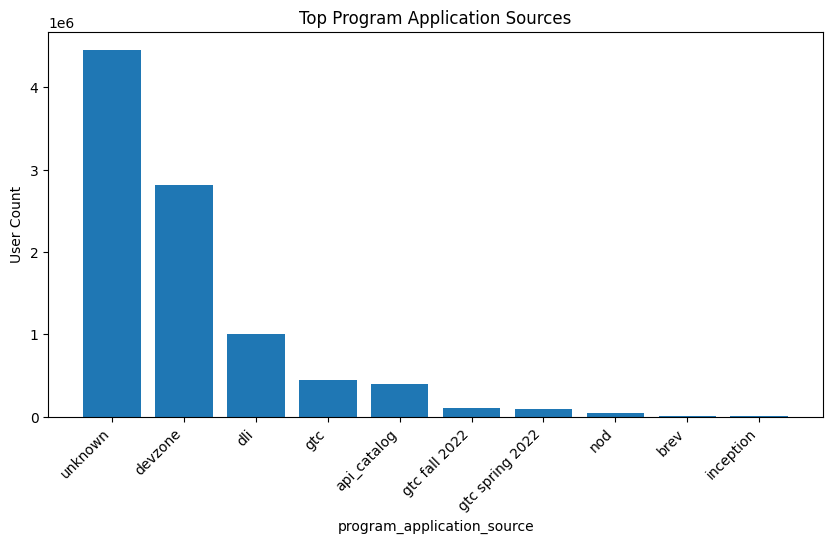

In [14]:
df = con.execute("""
SELECT program_application_source, COUNT(*) AS user_count
FROM developer_feature_base
GROUP BY 1
ORDER BY user_count DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10,5))
plt.bar(df["program_application_source"], df["user_count"])
plt.title("Top Program Application Sources")
plt.xlabel("program_application_source")
plt.ylabel("User Count")
plt.xticks(rotation=45, ha="right")
plt.show()

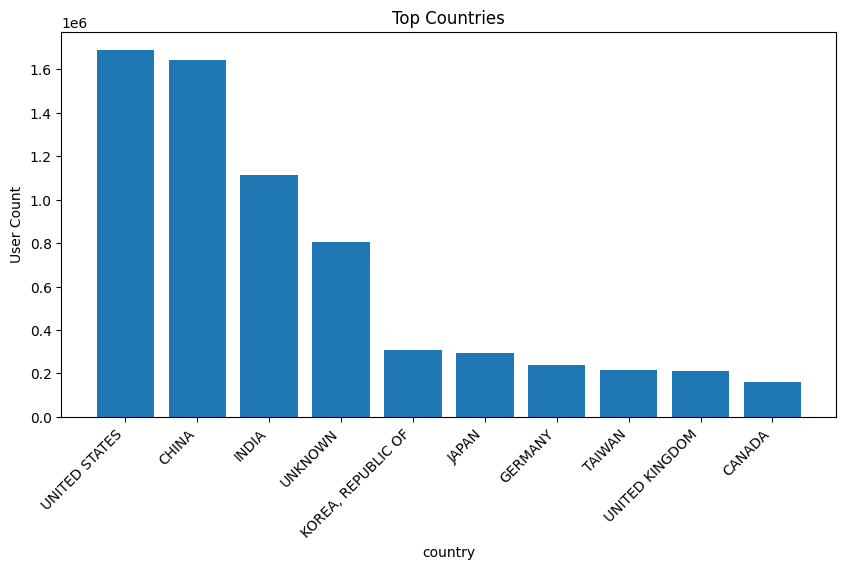

In [15]:
df = con.execute("""
SELECT country, COUNT(*) AS user_count
FROM developer_feature_base
GROUP BY 1
ORDER BY user_count DESC
LIMIT 10
""").fetchdf()

plt.figure(figsize=(10,5))
plt.bar(df["country"], df["user_count"])
plt.title("Top Countries")
plt.xlabel("country")
plt.ylabel("User Count")
plt.xticks(rotation=45, ha="right")
plt.show()

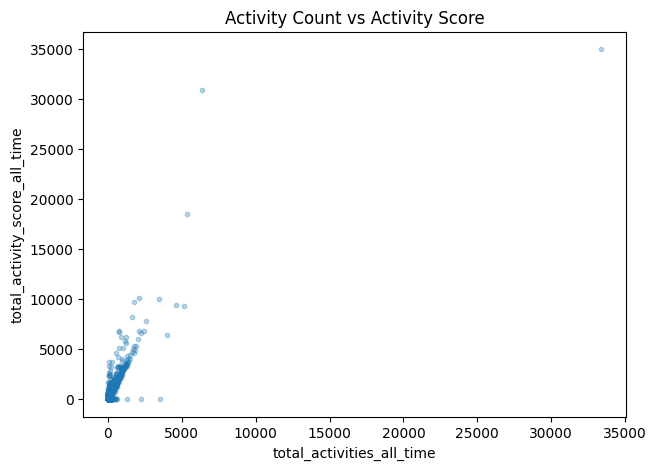

In [16]:
df = con.execute("""
SELECT
    total_activities_all_time,
    total_activity_score_all_time
FROM developer_feature_base
WHERE total_activities_all_time > 0
  AND total_activity_score_all_time > 0
LIMIT 100000
""").fetchdf()

plt.figure(figsize=(7,5))
plt.scatter(
    df["total_activities_all_time"],
    df["total_activity_score_all_time"],
    alpha=0.3,
    s=10
)
plt.title("Activity Count vs Activity Score")
plt.xlabel("total_activities_all_time")
plt.ylabel("total_activity_score_all_time")
plt.show()

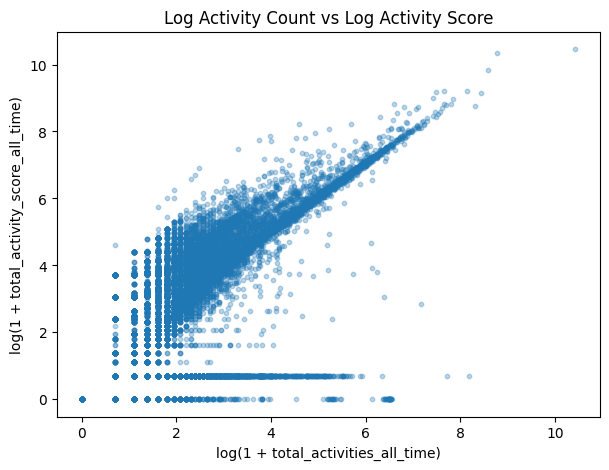

In [17]:
df = con.execute("""
SELECT
    LN(1 + total_activities_all_time) AS log_activities,
    LN(1 + total_activity_score_all_time) AS log_score
FROM developer_feature_base
WHERE total_activities_all_time >= 0
  AND total_activity_score_all_time >= 0
LIMIT 100000
""").fetchdf()

plt.figure(figsize=(7,5))
plt.scatter(
    df["log_activities"],
    df["log_score"],
    alpha=0.3,
    s=10
)
plt.title("Log Activity Count vs Log Activity Score")
plt.xlabel("log(1 + total_activities_all_time)")
plt.ylabel("log(1 + total_activity_score_all_time)")
plt.show()

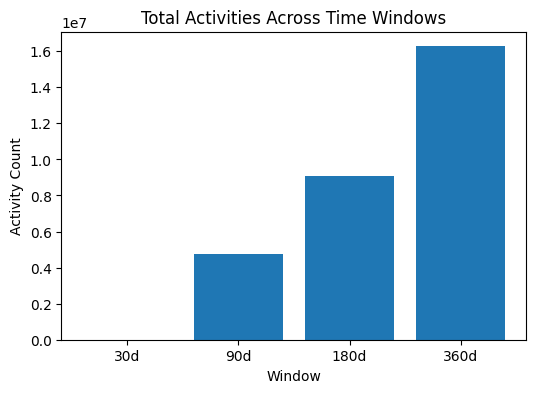

In [18]:
df = con.execute("""
SELECT
    SUM(activity_cnt_30d) AS cnt_30d,
    SUM(activity_cnt_90d) AS cnt_90d,
    SUM(activity_cnt_180d) AS cnt_180d,
    SUM(activity_cnt_360d) AS cnt_360d
FROM developer_feature_base
""").fetchdf()

plot_df = pd.DataFrame({
    "Window": ["30d", "90d", "180d", "360d"],
    "Count": [
        df.loc[0, "cnt_30d"],
        df.loc[0, "cnt_90d"],
        df.loc[0, "cnt_180d"],
        df.loc[0, "cnt_360d"]
    ]
})

plt.figure(figsize=(6,4))
plt.bar(plot_df["Window"], plot_df["Count"])
plt.title("Total Activities Across Time Windows")
plt.xlabel("Window")
plt.ylabel("Activity Count")
plt.show()

In [19]:
con.close()